In [1]:
import arviz as az
import jax
import numpyro
import polars as pl
from jax import numpy as jnp
from numpyro import distributions as dist
from numpyro.infer import MCMC, NUTS 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

from matplotlib import pyplot as plt

numpyro.set_host_device_count(4)

In [2]:
scores = pl.read_csv("./data/raw/scores.csv")
max_score = scores.group_by("Game").agg(pl.col("Total").max().alias("max_score"))

scores = (
    scores.join(max_score, on="Game")
    .with_columns(
        (pl.col("Total") == pl.col("max_score")).alias("winner"),
        pl.when(pl.col("Expansions").eq("EE"))
        .then(pl.lit("Europe"))
        .when(pl.col("Expansions").eq("AE"))
        .then(pl.lit("Asia"))
        .when(pl.col("Expansions").eq("EE,OE"))
        .then(pl.lit("Oceania"))
        .when(pl.col("Expansions").eq("EE,OE,AE"))
        .then(pl.lit("All"))
        .otherwise(pl.lit("Other"))
        .alias("Expansions")
    )
    .select(pl.exclude("max_score"))
    .with_columns(
        ((pl.col(col) / pl.col("Total")).alias(f"{col.lower().replace(" ", "_")}_pct")
        for col in ["Birds", "Bonus Cards", "Food on Cards", "Eggs", "Tucked Cards", "Nectar", "Duet Tokens"])
    )
)

scores.head()


Game,Expansions,Player,Birds,Bonus Cards,End of Round Goals,Eggs,Food on Cards,Tucked Cards,Nectar,Duet Tokens,Total,winner,birds_pct,bonus_cards_pct,food_on_cards_pct,eggs_pct,tucked_cards_pct,nectar_pct,duet_tokens_pct
i64,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,bool,f64,f64,f64,f64,f64,f64,f64
1,"""Europe""","""Yizhou""",28,6,7,26,0,26,0,0,93,false,0.301075,0.064516,0.0,0.27957,0.27957,0.0,0.0
1,"""Europe""","""Sam""",30,7,12,13,0,41,0,0,103,true,0.291262,0.067961,0.0,0.126214,0.398058,0.0,0.0
1,"""Europe""","""Camille""",38,6,9,13,0,8,0,0,74,false,0.513514,0.081081,0.0,0.175676,0.108108,0.0,0.0
1,"""Europe""","""Matt""",32,7,7,25,1,19,0,0,91,false,0.351648,0.076923,0.010989,0.274725,0.208791,0.0,0.0
2,"""Europe""","""Camille""",34,6,20,22,5,7,0,0,94,false,0.361702,0.06383,0.053191,0.234043,0.074468,0.0,0.0


In [23]:
preprocessor = ColumnTransformer(
    [
        ("encoder", OrdinalEncoder(), ["Expansions", "Player"]),
        (
            "pass",
            "passthrough",
            [
                "Birds",
                "Bonus Cards",
                "End of Round Goals",
                "Eggs",
                "Food on Cards",
                "Tucked Cards",
                "Nectar",
                "Duet Tokens",
                "winner"
            ],
        ),
    ]
)

score_data = preprocessor.fit_transform(scores)

players = score_data[:, 1].astype(jnp.int16)
expansions = score_data[:, 0].astype(jnp.int16)
winner = score_data[:, -1].astype(jnp.int16)
points = score_data[:, 2:-1]

# print(score_data[:5])

preprocessor.transformers_[0][1].categories_
point_categories = preprocessor.transformers_[1][1].get_feature_names_out()[:-1]
expansion_labels = preprocessor.transformers_[0][1].categories_[0]
player_names = preprocessor.transformers_[0][1].categories_[1]
print(point_categories)
print(expansion_labels)
print(player_names)


['Birds' 'Bonus Cards' 'End of Round Goals' 'Eggs' 'Food on Cards'
 'Tucked Cards' 'Nectar' 'Duet Tokens']
['All' 'Asia' 'Europe' 'Oceania']
['A' 'B' 'Camille' 'Dad' 'J' 'Jon' 'Joy' 'Matt' 'Mom' 'Sam' 'T' 'Yizhou']


In [58]:
def model(expansions, players, counts):
    """
    category_counts: array (n_players, n_categories), raw point counts
    """
    N, K = counts.shape
    total = jnp.sum(counts, axis=1)
    n_players = len(np.unique(players))

    point_mask = jnp.array(
        [
            # Birds, Bonus Cards, End of Round Goals, Eggs, Food on Cards, Tucked Cards, Nectar, Duet Tokens  
            [
                1, 1, 1, 1, 1, 1, 1, 1  # All
            ],
            [
                1, 1, 0, 1, 1, 1, 1, 1 # Asia
            ],
            [
                1, 1, 1, 1, 1, 1, 0, 0 # Europe
            ],
            [
                1, 1, 1, 1, 1, 1, 1, 0 # Oceania
            ],
        ],
    )
    
    # global base distribution across categories
    phi = numpyro.sample("phi", dist.Dirichlet(jnp.ones(K)))
    point_mean = numpyro.sample("point_mean", dist.Normal(70., 10))
    point_sigma = numpyro.sample("point_sigma", dist.HalfNormal(15.))
    with numpyro.plate("categories", K):
        log_eta = numpyro.sample("log_eta", dist.Normal(0., 1.))
        eta = jnp.exp(log_eta) 

    conc = eta * phi * point_mask + 0.2
    with numpyro.plate("expansions", 4):
        with numpyro.plate("players", n_players):
            point_lambda = numpyro.sample("total_points", dist.Normal(point_mean, point_sigma))
            theta = numpyro.sample(f"phi_exp", dist.Dirichlet(conc))

    point_eps = numpyro.sample("point_eps", dist.HalfNormal(5.))
    with numpyro.plate("obs", N):
        numpyro.sample("obs_counts", dist.Multinomial(total_count=total, probs=theta[players, expansions]),
                       obs=counts)
        numpyro.sample("obs_total", dist.Normal(point_lambda[players, expansions], point_eps), obs=total)

kernel = NUTS(model)
mcmc = MCMC(kernel, num_warmup=3000, num_samples=1000, num_chains=4)

key = jax.random.key(481)

mcmc.run(
    key,
    expansions=expansions,
    players=players,
    counts=points
)

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

  0%|          | 0/4000 [00:00<?, ?it/s]

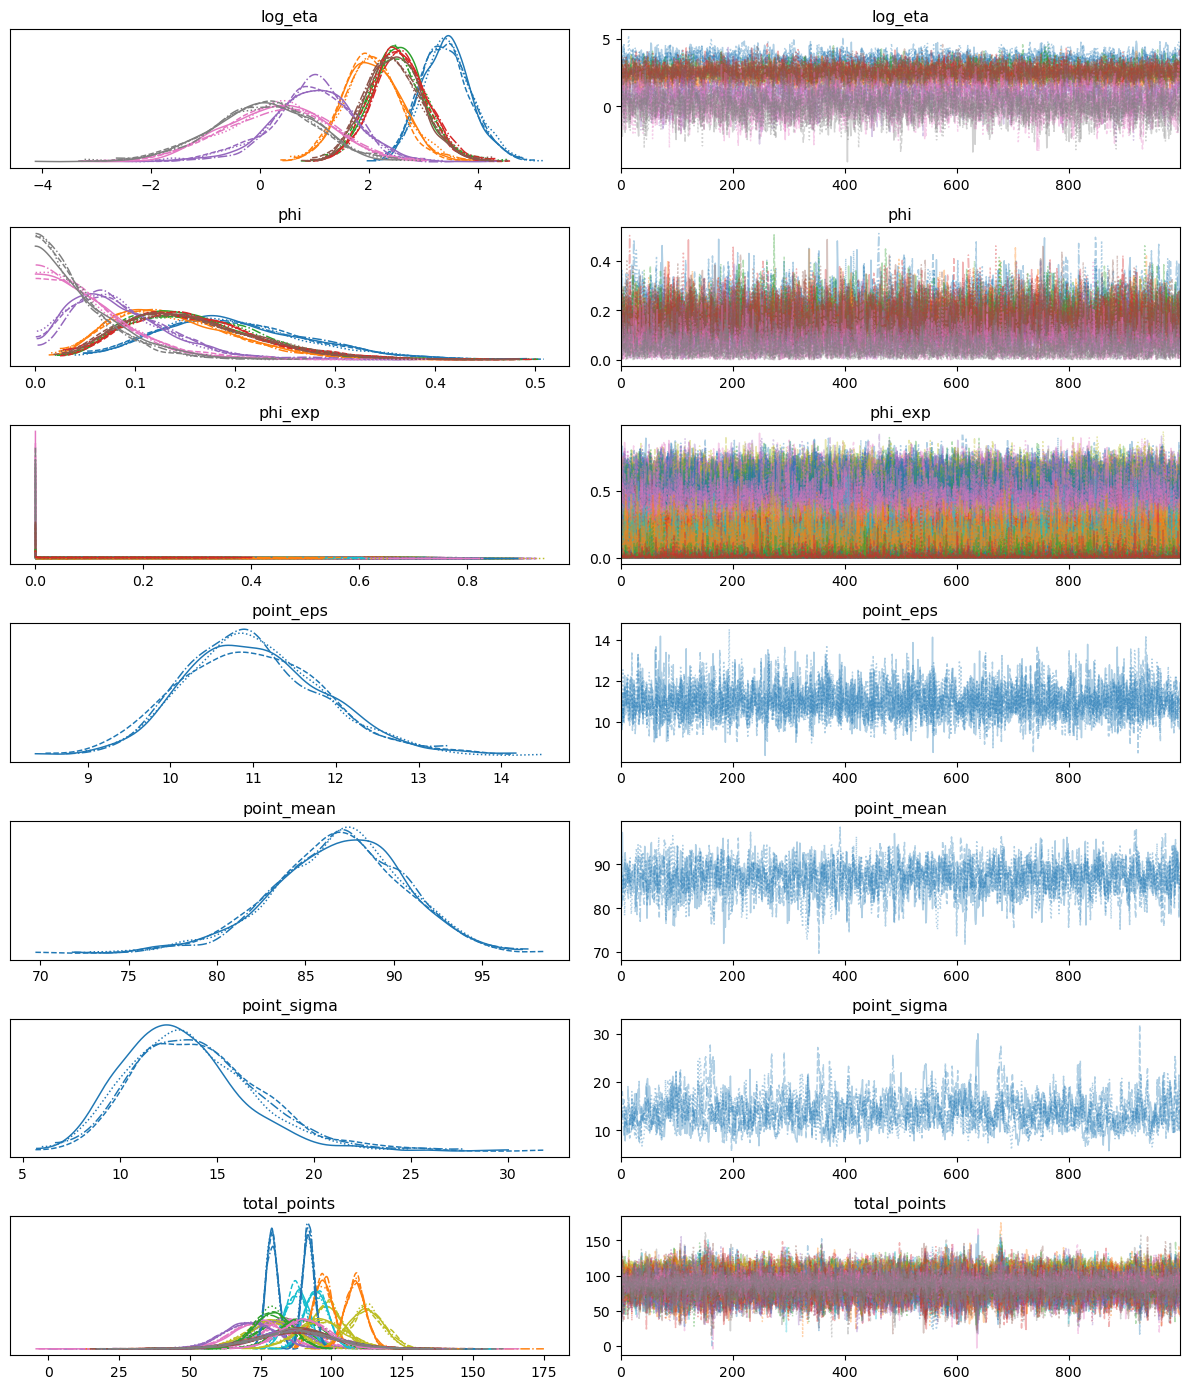

In [59]:
trace = az.from_numpyro(
    mcmc,
    coords={
        "players": player_names,
        "expansions": expansion_labels,
        "point_categories": point_categories,
    },
    dims={
        "phi": ["point_categories"],
        "point_totals": ["point_categories"],
        "phi_exp": ["players", "expansions", "point_categories"],
        "total_points": ["players", "expansions"]
    },
)

az.plot_trace(
    trace,
    # figsize=(12, 8),
    # coords={"players": ["Matt"]}
)
plt.tight_layout()

array([<Axes: title={'center': '90.0% HDI'}>], dtype=object)

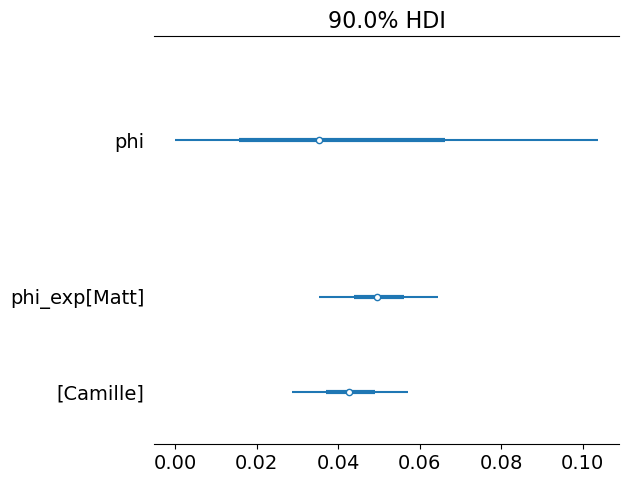

In [66]:
az.plot_forest(
    trace,
    var_names=["phi", "phi_exp"],
    combined=True,
    coords={"expansions": ["Asia"], "point_categories": ["Duet Tokens"], "players": ["Matt", "Camille"]},
    hdi_prob=0.90,
)

In [61]:
fn = numpyro.infer.Predictive(mvn_model, mcmc.get_samples(), return_sites=["total_points", "nectar_points"])

pred_X = pl.DataFrame(
    {
        "Expansions": ["Europe", "Europe", "Asia", "Asia", "Oceania", "Oceania", "All", "All"],
        "Player": ["Matt", "Camille", "Matt", "Camille", "Matt", "Camille", "Matt", "Camille"],
    }
)
input_data = jnp.array(preprocessor.transformers_[0][1].transform(pred_X)).astype(jnp.int16)

sim_points = fn(
    jax.random.PRNGKey(62628),
    expansions=input_data[:, 0],
    players=input_data[:, 1],
)



NameError: name 'mvn_model' is not defined

In [48]:
points = sim_points["total_points"]
for i, exp in zip(range(0, 8, 2), ["Europe", "Asia", "Oceania", "All"]):
    print(f"Prob Matt Win ({exp}): {(points[:, i] > points[:, i+1]).mean():0.4f}")

Prob Matt Win (Europe): 0.7878
Prob Matt Win (Asia): 0.6193
Prob Matt Win (Oceania): 0.7225
Prob Matt Win (All): 0.7550


In [50]:
sim_points["nectar_points"].shape

(4000,)